https://www.datacamp.com/tutorial/corrective-rag-crag

In [ ]:
%%capture
!pip install langchain_community tiktoken langchain-openai langchainhub chromadb langchain langgraph tavily-python

In [ ]:
from langchain_openai import AzureChatOpenAI, AzureOpenAIEmbeddings
from google.colab import userdata

llm = AzureChatOpenAI(
    model=userdata.get('AZURE_MODEL_NAME'),
    deployment_name=userdata.get('AZURE_MODEL_NAME'),
    temperature=0,
    # max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=userdata.get('AZURE_API_KEY'),  # if you prefer to pass api key in directly instaed of using env vars
    azure_endpoint=userdata.get('AZURE_BASE_URL'),
    api_version=userdata.get('AZURE_API_VERSION'),
)

emd = AzureOpenAIEmbeddings(
    model=userdata.get('AZURE_EMBEDDING_NAME'),
    api_key=userdata.get('AZURE_API_KEY'),
    azure_endpoint=userdata.get('AZURE_BASE_URL'),
    api_version=userdata.get('AZURE_API_VERSION'),
)


In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
urls = [
    "https://ryanocm.substack.com/p/mystery-gift-box-049-law-1-fill-your",
    "https://ryanocm.substack.com/p/105-the-bagel-method-in-relationships",
    "https://ryanocm.substack.com/p/098-i-have-read-100-productivity",
]
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=250, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(docs_list)
# Add to vectorDB
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=emd,
)
retriever = vectorstore.as_retriever()

In [ ]:
### Generate
from langchain import hub
from langchain_core.output_parsers import StrOutputParser
# Prompt
rag_prompt = hub.pull("rlm/rag-prompt")
# LLM
rag_llm = llm
# Post-processing
def format_docs(docs):
    return "\\n\\n".join(doc.page_content for doc in docs)
# Chain
rag_chain = rag_prompt | rag_llm | StrOutputParser()
print(rag_prompt.messages[0].prompt.template)

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


/usr/local/lib/python3.10/dist-packages/langsmith/client.py:323: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [ ]:
question = "what is the bagel method"
generation = rag_chain.invoke({"context": doc_splits, "question": question})
print("Question: %s" % question)
print("----")
print("Documents:")
print(' '.join(['- %s' % x.page_content for x in doc_splits]))
print("----")
print("Final answer: %s" % generation)

Question: what is the bagel method
----
Documents:
- Mystery Gift Box #049 | Law 1: Fill your Five Buckets in the Right Order (The Diary of a CEO) - The Limitless Playbook üß¨SubscribeSign inShare this postMystery Gift Box #049 | Law 1: Fill your Five Buckets in the Right Order (The Diary of a CEO)ryanocm.substack.comCopy linkFacebookEmailNoteOtherMystery Gift Box #049 | Law 1: Fill your Five Buckets in the Right Order (The Diary of a CEO)The best hidden gems I've found; interesting ideas and concepts, thought-provoking questions, mind-blowing books/podcasts, cool animes/films, and other mysteries ‚ù§Ô∏èRyan Ong üéÆSep 10, 2023Share this postMystery Gift Box #049 | Law 1: Fill your Five Buckets in the Right Order (The Diary of a CEO)ryanocm.substack.comCopy linkFacebookEmailNoteOtherShareHey friends,Steven Bartlett‚Äôs new book The Diary of a CEO: The 33 Laws of Business and Life.I have been obsess with The Diary of a CEO podcast for the last few years. It‚Äôs one of my favourite pod

In [ ]:
format_docs(doc_splits)

"Mystery Gift Box #049 | Law 1: Fill your Five Buckets in the Right Order (The Diary of a CEO)\\n\\nThe Limitless Playbook \uf8ffüß¨SubscribeSign inShare this postMystery Gift Box #049 | Law 1: Fill your Five Buckets in the Right Order (The Diary of a CEO)ryanocm.substack.comCopy linkFacebookEmailNoteOtherMystery Gift Box #049 | Law 1: Fill your Five Buckets in the Right Order (The Diary of a CEO)The best hidden gems I've found; interesting ideas and concepts, thought-provoking questions, mind-blowing books/podcasts, cool animes/films, and other mysteries ‚ù§Ô∏èRyan Ong \uf8ffüéÆSep 10, 2023Share this postMystery Gift Box #049 | Law 1: Fill your Five Buckets in the Right Order (The Diary of a CEO)ryanocm.substack.comCopy linkFacebookEmailNoteOtherShareHey friends,Steven Bartlett‚Äôs new book The Diary of a CEO: The 33 Laws of Business and Life.I have been obsess with The Diary of a CEO podcast for the last few years. It‚Äôs one of my favourite podcasts\\n\\nand so when Steven Bartlett‚

In [ ]:
### Retrieval Evaluator
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
# Data model
class RetrievalEvaluator(BaseModel):
    """Classify retrieved documents based on how relevant it is to the user's question."""
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )
# LLM with function call
retrieval_evaluator_llm = llm
structured_llm_evaluator = retrieval_evaluator_llm.with_structured_output(RetrievalEvaluator)
# Prompt
system = """You are a document retrieval evaluator that's responsible for checking the relevancy of a retrieved document to the user's question. \\n
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \\n
    Output a binary score 'yes' or 'no' to indicate whether the document is relevant to the question."""
retrieval_evaluator_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \\n\\n {document} \\n\\n User question: {question}"),
    ]
)
retrieval_grader = retrieval_evaluator_prompt | structured_llm_evaluator

In [ ]:
### Question Re-writer
# LLM
question_rewriter_llm = llm
# Prompt
system = """You are a question re-writer that converts an input question to a better version that is optimized \\n
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \\n\\n {question} \\n Formulate an improved question.",
        ),
    ]
)
question_rewriter = re_write_prompt | question_rewriter_llm | StrOutputParser()

In [ ]:
%%capture
from langchain_community.tools.tavily_search import TavilySearchResults
%env TAVILY_API_KEY={userdata.get("TAVILY_API_KEY")}
web_search_tool = TavilySearchResults(k=3)

In [ ]:
web_search_tool.run("what is the bagel method")

[{'url': 'https://www.bagelfest.com/blog/the-art-of-the-new-york-bagel-a-step-by-step-guide-to-making-the-perfect-bagel',
  'content': 'There are mainly two methods to shape bagels: the "rope and loop" method and the "poke and stretch" method. Rope and Loop Method. This is the traditional method for shaping bagels and is often used by professional bagel shops. The process involves rolling the dough into a long rope, about 6-10 inches long, depending on the size of the ...'},
 {'url': 'https://www.sophisticatedgourmet.com/2009/10/new-york-style-bagel-recipe/',
  'content': 'There are many methods in which you can shape a bagel; there is a more traditional method that many bagel shops use- you roll the bagel dough into logs and bind the ends together. The method used here is done by simply poking the hole in the middle of taught rounds of bagel dough. Once that is done, the bagel rings are gently stretched to ...'},
 {'url': 'https://www.kingarthurbaking.com/blog/2021/06/29/the-5-element

In [ ]:
from typing import List
from typing_extensions import TypedDict
class GraphState(TypedDict):
    """
    Represents the state of our graph.
    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """
    question: str
    generation: str
    web_search: str
    documents: List[str]

In [ ]:
from langchain.schema import Document
def retrieve(state):
    """
    Retrieve documents
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]
    # Retrieval
    documents = retriever.get_relevant_documents(question)
    return {"documents": documents, "question": question}

In [ ]:
def generate(state):
    """
    Generate answer
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

In [ ]:
def evaluate_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """
    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]
    # Score each doc
    filtered_docs = []
    web_search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    if len(filtered_docs) / len(documents) <= 0.7:
        web_search = "Yes"
    return {"documents": filtered_docs, "question": question, "web_search": web_search}

In [ ]:
def transform_query(state):
    """
    Transform the query to produce a better question.
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): Updates question key with a re-phrased question
    """
    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]
    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}

In [ ]:
def web_search(state):
    """
    Web search based on the re-phrased question.
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): Updates documents key with appended web results
    """
    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]
    # Web search
    docs = web_search_tool.invoke({"query": question})
    web_results = "\\n".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)
    documents.append(web_results)
    return {"documents": documents, "question": question}

In [ ]:
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.
    Args:
        state (dict): The current graph state
    Returns:
        str: Binary decision for next node to call
    """
    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]
    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

In [ ]:
from langgraph.graph import END, StateGraph, START
workflow = StateGraph(GraphState)
# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", evaluate_documents)  # evaluate documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search
# Build graph
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)
# Compile
app = workflow.compile()

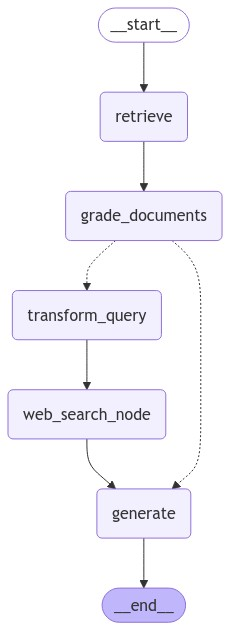

In [ ]:
from IPython.display import Image, display
try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
from pprint import pprint
# Run
inputs = {"question": "What's the bagel method?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        pprint(value, indent=2, width=80, depth=None)
    pprint("\\n---\\n")
# Final generation
pprint(value["generation"])

---RETRIEVE---


<ipython-input-75-f3f562756548>:13: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  documents = retriever.get_relevant_documents(question)


"Node 'retrieve':"
{ 'documents': [ Document(metadata={'description': 'A collection of the best hidden gems, mental models, and frameworks from the world‚Äôs top thinkers; to help you become 1% better and live a happier life ‚ù§Ô∏è', 'language': 'en', 'source': 'https://ryanocm.substack.com/p/105-the-bagel-method-in-relationships', 'title': '#105 | The Bagel Method in Relationships \uf8ffü•Ø'}, page_content='#105 | The Bagel Method in Relationships \uf8ffü•Ø'),
                 Document(metadata={'description': 'A collection of the best hidden gems, mental models, and frameworks from the world‚Äôs top thinkers; to help you become 1% better and live a happier life ‚ù§Ô∏è', 'language': 'en', 'source': 'https://ryanocm.substack.com/p/105-the-bagel-method-in-relationships', 'title': '#105 | The Bagel Method in Relationships \uf8ffü•Ø'}, page_content="these information send straight to your inbox every Sunday \uf8ffü•≥Subscribe\uf8ffü•Ø The Bagel MethodThe Bagel Method involves mapping out 

In [ ]:
from pprint import pprint
# Run
inputs = {"question": "What is prompt engineering?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        pprint(value, indent=2, width=80, depth=None)
    pprint("\\n---\\n")
# Final generation
pprint(value["generation"])

---RETRIEVE---
"Node 'retrieve':"
{ 'documents': [ Document(metadata={'description': "The best hidden gems I've found; interesting ideas and concepts, thought-provoking questions, mind-blowing books/podcasts, cool animes/films, and other mysteries ‚ù§Ô∏è", 'language': 'en', 'source': 'https://ryanocm.substack.com/p/mystery-gift-box-049-law-1-fill-your', 'title': 'Mystery Gift Box #049 | Law 1: Fill your Five Buckets in the Right Order (The Diary of a CEO)'}, page_content='rest should handle themselves. Knowledge and skills are the foundation of which you build your life and career and it‚Äôs truly yours to own; you can lose your network, resources, and reputation but you will never lose your knowledge and skills.Never try to skip the first two buckets. If you try to jump straight to network, resources, and / or reputation bucket, you might ‚Äúsucceed‚Äù in the short-run but in the long run, your lack of knowledge and skill will catch on to you.There is no skipping the first two buckets